# 01 - Load and exploratory data analysis

**What you will learn**
- How to load a whitespace-delimited flat file into pandas with named
  columns.
- How to describe a run-to-failure dataset (engines, cycles, per-engine
  length).
- How to spot *dead sensors* (constant values, no information).
- How to identify the 6 operating regimes hiding inside the operational
  settings, and why that matters for feature engineering.
- Which sensors show a monotonic drift toward failure. These are the ones
  we will build features on.

Every finding here motivates a decision made in notebook 02.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Add repo root to sys.path so `from src.data import ...` works when the
# notebook is opened from the notebooks/ folder.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## 1. Load the training file

The loader is a thin wrapper around `pd.read_csv` that names the columns
for us. Look at `src/data.py`: it is about 30 lines and worth reading before
we call it.

In [2]:
from src.data import (
    load_fd004, load_rul_fd004, add_rul_train,
    SENSOR_COLS, OP_COND_COLS,
)

df = load_fd004("train")
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

shape: 61,249 rows x 26 columns


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


### What are the columns?

| Column | Meaning |
|--------|---------|
| `unit` | Engine ID (1 to 249 for training) |
| `cycle` | Operating cycle since the engine was installed. Row 1 = brand new, higher cycle = older. |
| `os1`, `os2`, `os3` | Operational settings: altitude, Mach number, throttle-resolver angle. Values change from cycle to cycle as the engine flies different missions. |
| `s1` to `s21` | 21 sensor channels: temperatures, pressures, fan speeds, fuel flow. This is what we will monitor. |

There is no label column. No cycle is pre-marked as anomalous. We will
derive labels in notebook 05 using the RUL (remaining useful life).

## 2. How many engines, how long do they run?

# engines: 249
cycles per engine: min=128, median=234, max=543


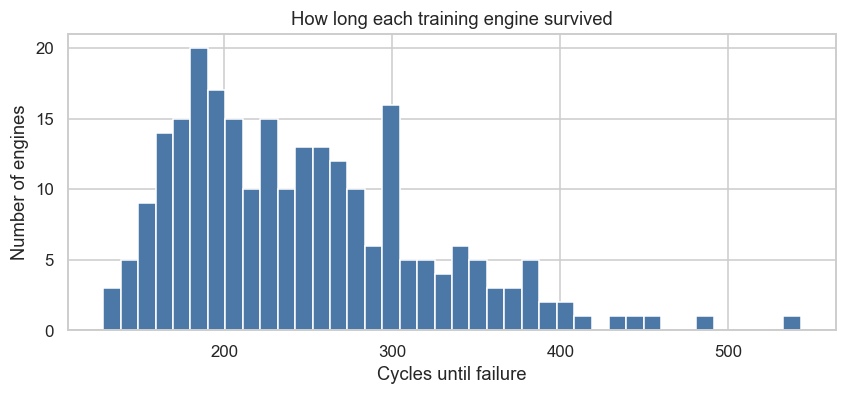

In [3]:
n_engines = df["unit"].nunique()
cycles_per_engine = df.groupby("unit")["cycle"].max()

print(f"# engines: {n_engines}")
print(
    f"cycles per engine: min={cycles_per_engine.min()}, "
    f"median={int(cycles_per_engine.median())}, max={cycles_per_engine.max()}"
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(cycles_per_engine, bins=40, color="#4c78a8", edgecolor="white")
ax.set_xlabel("Cycles until failure")
ax.set_ylabel("Number of engines")
ax.set_title("How long each training engine survived")
plt.show()

**Reading the plot.** Engines fail across a wide range: the shortest
lives are around 130 cycles, the longest past 500. That variability is real
(different fault mixes, different operating profiles) and it means we
cannot say "trigger the alarm at cycle 200" for every engine. The threshold
must be about the *state* of the sensors, not the age of the engine.

## 3. Append the true RUL to each row

For training data we know when each engine failed (its last recorded cycle).
That means for any earlier cycle we can compute the *remaining useful life*
as `max_cycle - current_cycle`. This is needed later for evaluation.

In [4]:
df = add_rul_train(df)
df[["unit", "cycle", "rul"]].head()

,unit,cycle,rul
0,1,1,320
1,1,2,319
2,1,3,318
3,1,4,317
4,1,5,316


In [5]:
# Sanity check: the last row of every engine should have RUL = 0.
last = df.sort_values("cycle").groupby("unit").tail(1)
assert (last["rul"] == 0).all(), "RUL not zero at failure. Loader bug?"
print("OK: RUL is 0 at the failure cycle for every engine")

OK: RUL is 0 at the failure cycle for every engine


## 4. One engine's trajectory

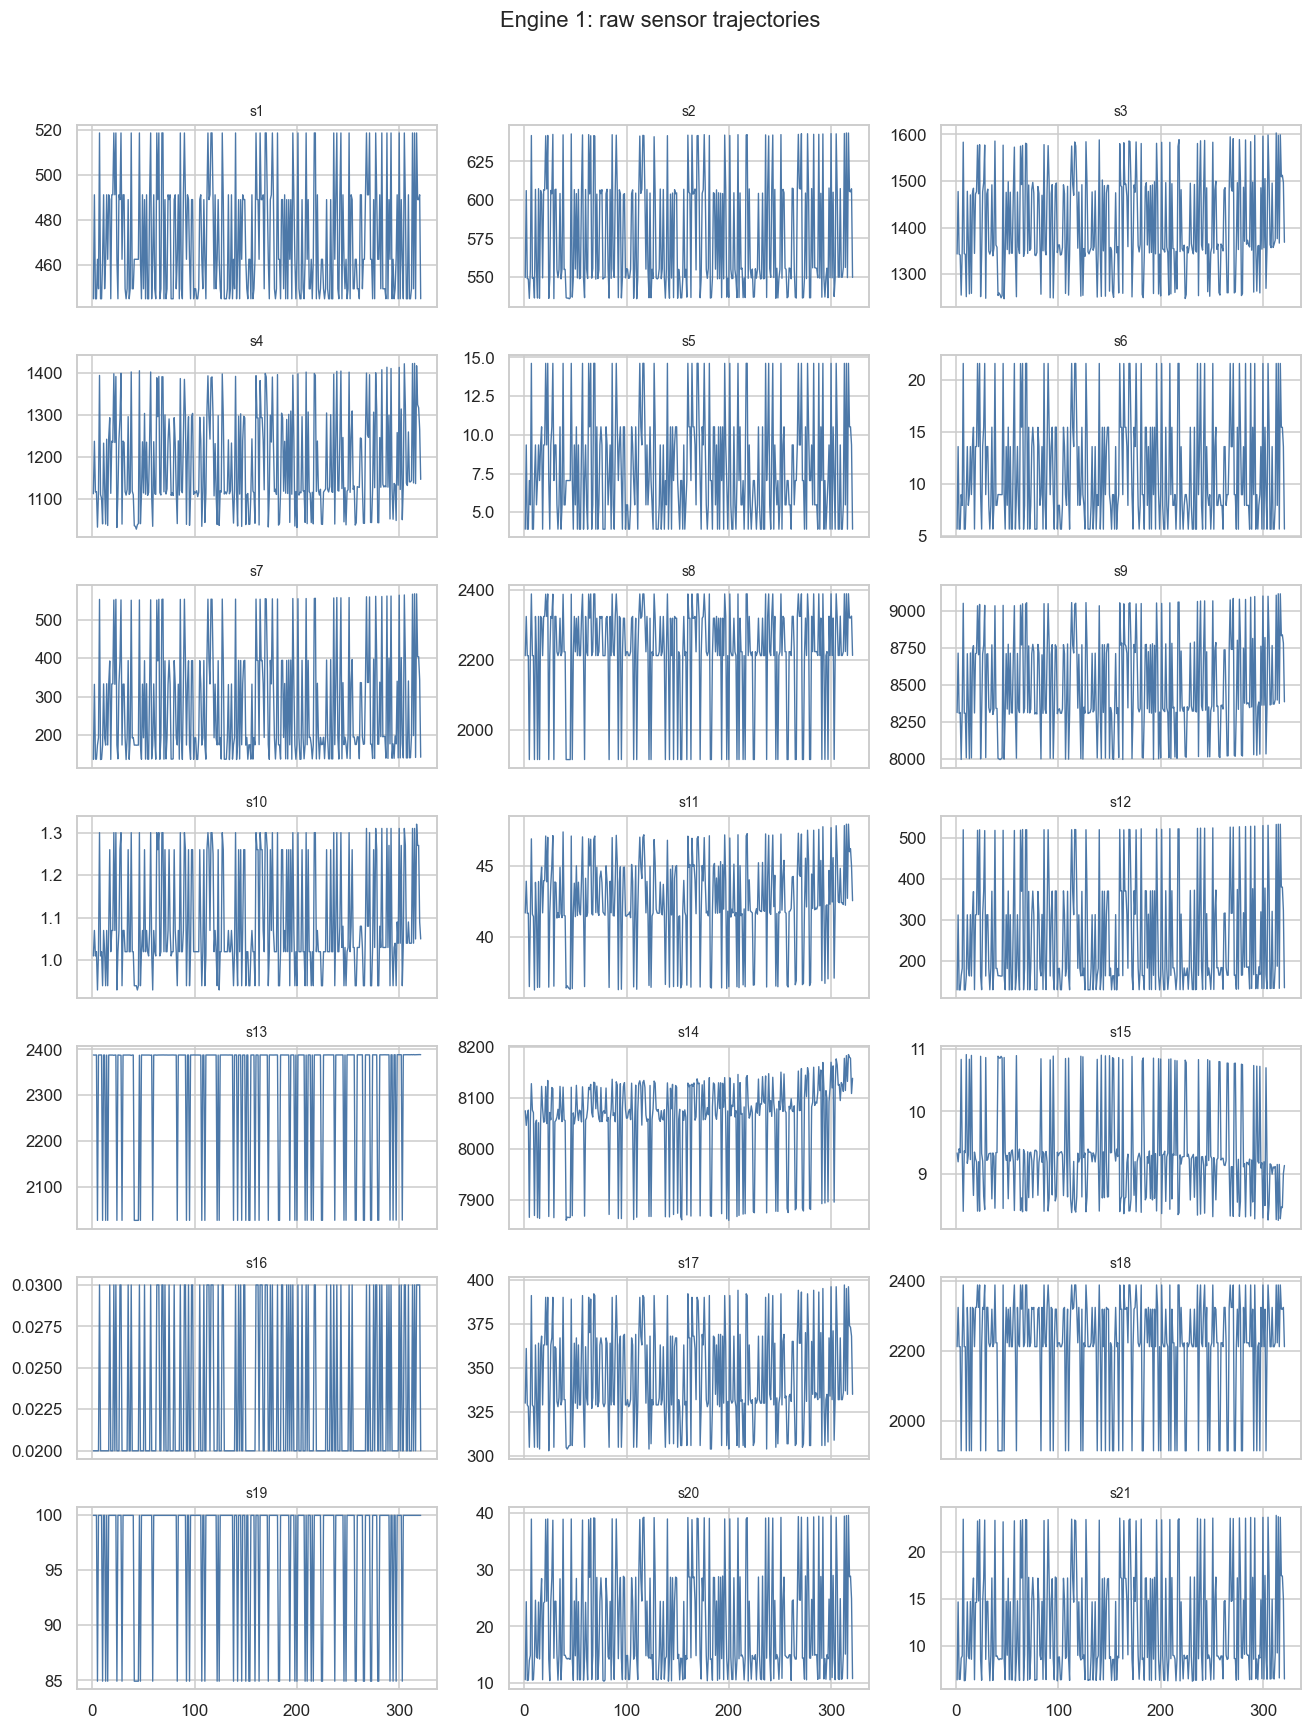

In [6]:
def plot_engine_sensors(df, unit, sensors, ncols=3):
    sub = df[df["unit"] == unit].sort_values("cycle")
    n = len(sensors)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(ncols * 4, nrows * 2.2), sharex=True
    )
    for ax, s in zip(np.array(axes).flatten(), sensors):
        ax.plot(sub["cycle"], sub[s], color="#4c78a8", linewidth=0.9)
        ax.set_title(s, fontsize=9)
    for ax in np.array(axes).flatten()[len(sensors):]:
        ax.set_visible(False)
    fig.suptitle(f"Engine {unit}: raw sensor trajectories", y=1.02)
    fig.tight_layout()
    plt.show()

plot_engine_sensors(df, unit=1, sensors=SENSOR_COLS)

**Reading the plot.** Two observations to act on:

1. **Some sensors are flat lines.** s1, s5, s18, s19 are constant for this
   engine, and s6, s10, s16 vary within a very narrow band. All of these
   look like dead channels at a glance. Notebook 02 will apply a stricter
   *per-regime* test and confirm that s1, s5, s18, s19 are the truly dead
   ones (the others carry a small but non-zero signal within each regime).

2. **Some sensors have large cycle-to-cycle jitter** even though the
   engine is nowhere near failure. That jitter is real: it comes from the
   engine flying different operating conditions from one cycle to the next.
   The next section shows why that matters.

## 5. The 6 operating regimes

Look at the three `os*` columns for engine 1:

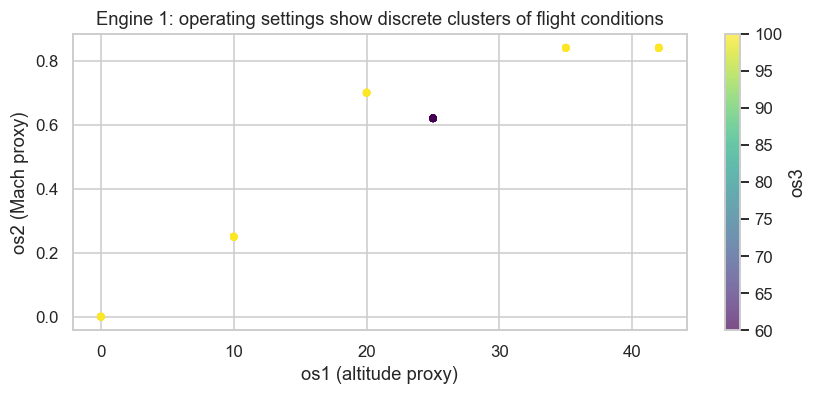

In [7]:
sub = df[df["unit"] == 1].sort_values("cycle")
fig, ax = plt.subplots(figsize=(9, 3.5))
sc = ax.scatter(
    sub["os1"], sub["os2"], c=sub["os3"], cmap="viridis", s=14, alpha=0.7
)
ax.set_xlabel("os1 (altitude proxy)")
ax.set_ylabel("os2 (Mach proxy)")
ax.set_title(
    "Engine 1: operating settings show discrete clusters of flight conditions"
)
plt.colorbar(sc, label="os3")
plt.show()

The scatter is not a cloud but a handful of discrete clusters. The
same engine flies a handful of distinct operating profiles (for example
cruise at high altitude vs takeoff at sea level), visiting them repeatedly
over its life. The next cell confirms there are exactly 6 across the whole
training set.

In [8]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=6, n_init=10, random_state=0)
regime = km.fit_predict(df[OP_COND_COLS].values)
df = df.assign(regime=regime)
print("Rows per regime:")
print(df["regime"].value_counts().sort_index())

Rows per regime:
regime
0    15395
1     9224
2     9139
3     9238
4     9091
5     9162
Name: count, dtype: int64


**Why this matters.** Look at sensor s2 (a temperature) without
splitting by regime:

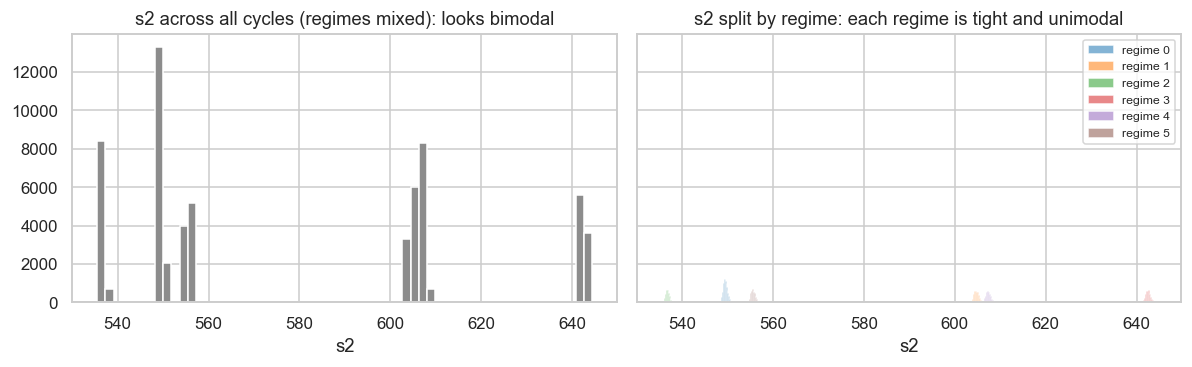

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

axes[0].hist(df["s2"], bins=60, color="#8c8c8c", edgecolor="white")
axes[0].set_title("s2 across all cycles (regimes mixed): looks bimodal")
axes[0].set_xlabel("s2")

for r, color in zip(range(6), sns.color_palette("tab10", 6)):
    axes[1].hist(
        df.loc[df["regime"] == r, "s2"], bins=40, color=color, alpha=0.55,
        label=f"regime {r}", edgecolor="white", linewidth=0.5,
    )
axes[1].set_title("s2 split by regime: each regime is tight and unimodal")
axes[1].set_xlabel("s2")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

The apparent bimodality on the left is not a real bimodality. It is
six regimes stacked on top of each other. If we fed the raw sensor value to
an anomaly detector, it would happily flag every cruise cycle as different
from every takeoff cycle. That is not what we want. In notebook 02 we will
normalise each sensor *within its regime*, and the detectors will then
focus on the actual degradation, not the flight condition.

Rule of thumb learned here: always plot per-group histograms if you have a
categorical setting variable. Mixed populations produce fake anomalies.

## 6. Which sensors carry a degradation signal?

We want features that separate healthy from near-failure cycles.
The easiest way to identify which raw sensors carry a signal at all: compare
the mean sensor value in early-life vs late-life cycles, per regime.

In [10]:
# Split each engine's life into 'early' (first 30%) and 'late' (last 30%).
def life_bin(g):
    max_c = g["cycle"].max()
    return np.where(
        g["cycle"] < 0.3 * max_c, "early",
        np.where(g["cycle"] > 0.7 * max_c, "late", "mid"),
    )

df["life"] = df.groupby("unit", group_keys=False).apply(
    lambda g: pd.Series(life_bin(g), index=g.index)
)

# Mean sensor value in each (regime, life-bin) cell, focused on regime 0.
r0 = df[df["regime"] == 0]
summary = r0.groupby("life")[SENSOR_COLS].mean().loc[["early", "late"]].T
summary["abs_shift"] = (summary["late"] - summary["early"]).abs()
summary["norm_shift"] = summary["abs_shift"] / summary["early"].abs()
summary.sort_values("norm_shift", ascending=False).head(15).style.format("{:.4f}")

life,early,late,abs_shift,norm_shift
s4,1119.3117,1132.8761,13.5643,0.0121
s11,41.8660,42.3156,0.4496,0.0107
s10,1.0196,1.0274,0.0078,0.0076
s17,329.6458,331.9832,2.3373,0.0071
s12,130.5058,131.3895,0.8837,0.0068
s3,1349.0990,1358.1041,9.0051,0.0067
s7,138.6170,139.5073,0.8903,0.0064
s15,9.3430,9.3103,0.0326,0.0035
s9,8317.6909,8344.0787,26.3878,0.0032
s14,8082.5802,8104.4546,21.8743,0.0027


The top of that table is the shortlist of sensors that carry a
degradation signal in regime 0. They shift measurably from early life to
late life. In the next notebook we will build features from these sensors,
not all 21.

Below, one high-shift sensor (typically s4 or s11) is overlaid with a
low-shift sensor (s1 or s5) for a visual sanity check:

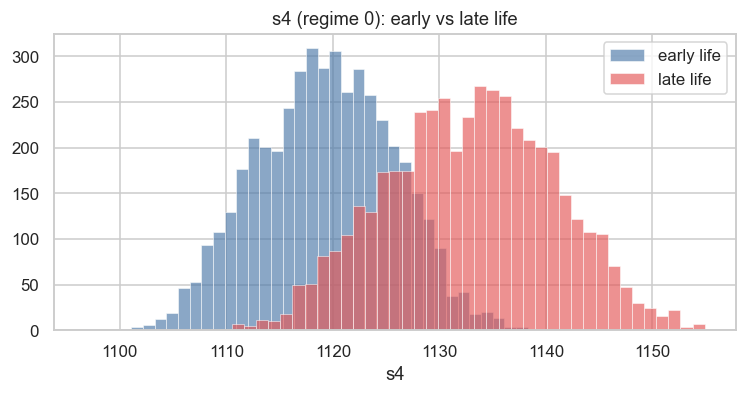

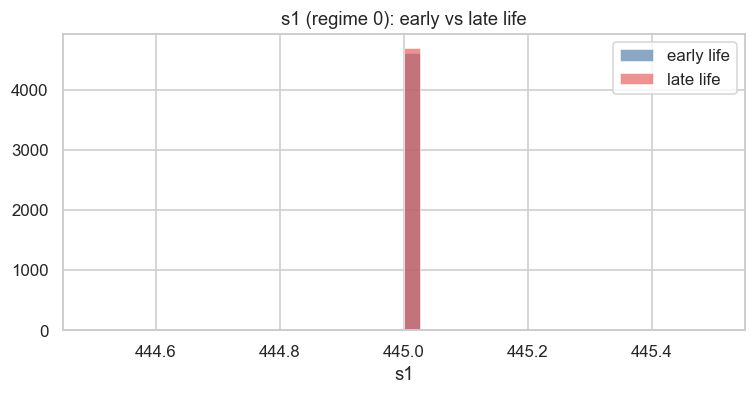

In [11]:
def overlay_healthy_vs_degraded(df, regime, sensor):
    r = df[df["regime"] == regime]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(
        r.loc[r["life"] == "early", sensor], bins=40,
        color="#4c78a8", alpha=0.65, label="early life",
        edgecolor="white", linewidth=0.5,
    )
    ax.hist(
        r.loc[r["life"] == "late", sensor], bins=40,
        color="#e45756", alpha=0.65, label="late life",
        edgecolor="white", linewidth=0.5,
    )
    ax.set_title(f"{sensor} (regime {regime}): early vs late life")
    ax.set_xlabel(sensor)
    ax.legend()
    plt.show()

overlay_healthy_vs_degraded(df, regime=0, sensor="s4")
overlay_healthy_vs_degraded(df, regime=0, sensor="s1")

**Reading the plots.** For s4 the late-life distribution has shifted
noticeably away from the early-life distribution. That is the degradation
signal we want to catch. For s1 the two distributions overlap almost
perfectly. This sensor is not useful and we will drop it in the next
notebook.

## 7. Correlations between sensors

Highly correlated sensors carry redundant information. Not a problem for
Isolation Forest (trees do not care about multicollinearity), but useful to
know when choosing which sensors to base features on. There is no point
engineering rolling means for both s7 and s8 if they are 99% correlated.

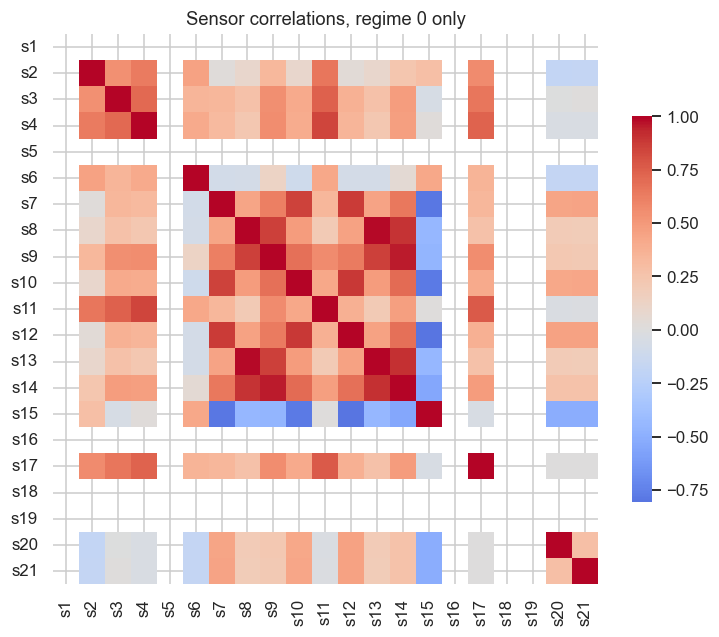

In [12]:
# Correlation on regime 0 only, so regime effects do not dominate.
alive = [s for s in SENSOR_COLS if df[s].nunique() > 1]
corr = df.loc[df["regime"] == 0, alive].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7},
    annot=False, xticklabels=True, yticklabels=True,
)
ax.set_title("Sensor correlations, regime 0 only")
plt.show()

## 8. Sanity-check the test set

Nothing to model here yet. Just confirm the loader works and the RUL file
lines up with the test engines.

In [13]:
test = load_fd004("test")
rul_test = load_rul_fd004()
print(f"test shape: {test.shape}")
print(f"# test engines: {test['unit'].nunique()}")
print(f"# RUL entries: {len(rul_test)}")
assert len(rul_test) == test["unit"].nunique()
print("OK: one RUL value per test engine")

test shape: (41214, 26)
# test engines: 248
# RUL entries: 248
OK: one RUL value per test engine


## Takeaways for notebook 02

Notebook 02 (feature engineering) will act on what we learned here:

1. **Drop dead sensors** (identified by near-zero standard deviation
   *within each operating regime*, not globally).
2. **Normalise every sensor within its operating regime**, so regime
   changes do not masquerade as anomalies.
3. **Focus feature engineering on the sensors that showed measurable early
   vs late shift** (top of the `norm_shift` table).
4. For each engineered feature, state the *hypothesis* the feature
   captures, the *math*, and a *validation plot* showing it separates
   healthy from near-failure cycles.